In [6]:
from keras.layers import Input, Dense
from keras.models import Model

# this is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# this is our input placeholder
input_img = Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = Dense(784, activation='sigmoid')(encoded)
# this model maps an input to its reconstruction
autoencoder = Model(input_img, decoded)
# this model maps an input to its encoded representation
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy')
from keras.datasets import mnist, fashion_mnist
import numpy as np
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

autoencoder.fit(x_train, x_train,
                epochs=5,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/5
235/235 [==============================] - 2s 6ms/step - loss: 0.6938 - val_loss: 0.6938
Epoch 2/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6937 - val_loss: 0.6936
Epoch 3/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6935 - val_loss: 0.6934
Epoch 4/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6933 - val_loss: 0.6933
Epoch 5/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6931 - val_loss: 0.6931


In [7]:
#Adding additional hidden layer

from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist, fashion_mnist
import numpy as np

# this is the size of our encoded representations
encoding_dim = 32
# this is our input placeholder
input_img = Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Adding an additional hidden layer
hidden_layer_dim = 64
hidden_layer = Dense(hidden_layer_dim, activation='relu')(encoded)

# "decoded" is the lossy reconstruction of the input, now connected to the hidden layer instead of 'encoded'
decoded = Dense(784, activation='sigmoid')(hidden_layer)

# this model maps an input to its reconstruction
autoencoder = Model(input_img, decoded)

# this model maps an input to its encoded representation
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy')

# Load and prepare the data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Train the model
autoencoder.fit(x_train, x_train,
                epochs=5,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/5
235/235 [==============================] - 3s 7ms/step - loss: 0.6943 - val_loss: 0.6942
Epoch 2/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6942 - val_loss: 0.6941
Epoch 3/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6940 - val_loss: 0.6939
Epoch 4/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6939 - val_loss: 0.6938
Epoch 5/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6937 - val_loss: 0.6937


Epoch 1/5
235/235 [==============================] - 3s 7ms/step - loss: 0.6943 - val_loss: 0.6942
Epoch 2/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6942 - val_loss: 0.6941
Epoch 3/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6941 - val_loss: 0.6940
Epoch 4/5
235/235 [==============================] - 1s 4ms/step - loss: 0.6940 - val_loss: 0.6939
Epoch 5/5
313/313 [==============================] - 1s 2ms/step


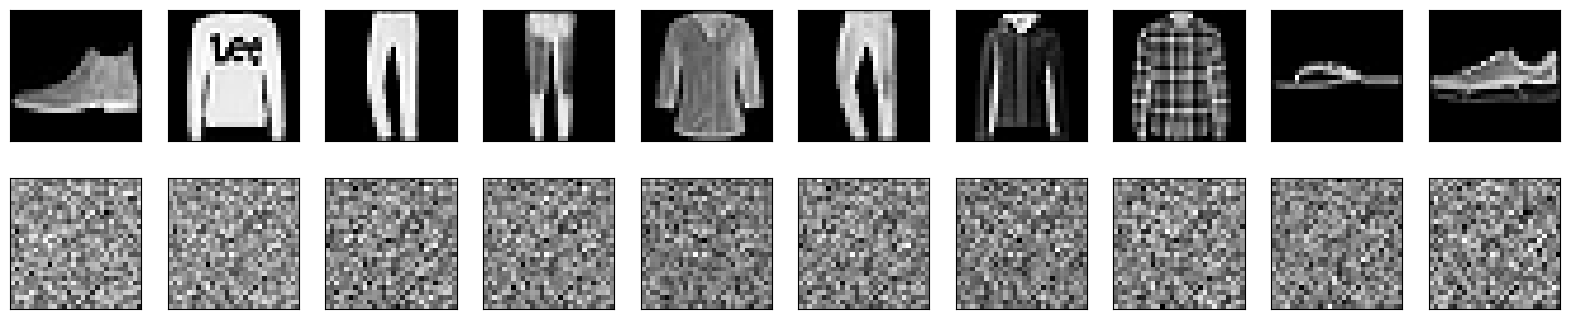

In [8]:
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist, fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# Define the model architecture
encoding_dim = 32
hidden_layer_dim = 64

input_img = Input(shape=(784,))
encoded = Dense(encoding_dim, activation='relu')(input_img)
hidden_layer = Dense(hidden_layer_dim, activation='relu')(encoded)  # Additional hidden layer
decoded = Dense(784, activation='sigmoid')(hidden_layer)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy')

# Load and prepare data
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Train the model
autoencoder.fit(x_train, x_train,
                epochs=5,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# Predict on the test data
decoded_imgs = autoencoder.predict(x_test)

# Visualize the original and reconstructed data
n = 10  # how many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/20
235/235 [==============================] - 2s 5ms/step - loss: 0.4282 - val_loss: 0.3566
Epoch 2/20
235/235 [==============================] - 1s 4ms/step - loss: 0.3511 - val_loss: 0.3350
Epoch 3/20
235/235 [==============================] - 1s 4ms/step - loss: 0.3381 - val_loss: 0.3350
Epoch 4/20
235/235 [==============================] - 1s 4ms/step - loss: 0.3317 - val_loss: 0.3239
Epoch 5/20
235/235 [==============================] - 1s 4ms/step - loss: 0.3277 - val_loss: 0.3174
Epoch 6/20
235/235 [==============================] - 1s 4ms/step - loss: 0.3251 - val_loss: 0.3154
Epoch 7/20
235/235 [==============================] - 1s 4ms/step - loss: 0.3236 - val_loss: 0.3139
Epoch 8/20
235/235 [==============================] - 1s 4ms/step - loss: 0.3223 - val_loss: 0.3129
Epoch 9/20
235/235 [==============================] - 1s 6ms/step - loss: 0.3213 - val_loss: 0.3132
Epoch 10/20
235/235 [==============================] - 1s 6ms/step - loss: 0.3202 - val_loss: 0.3108

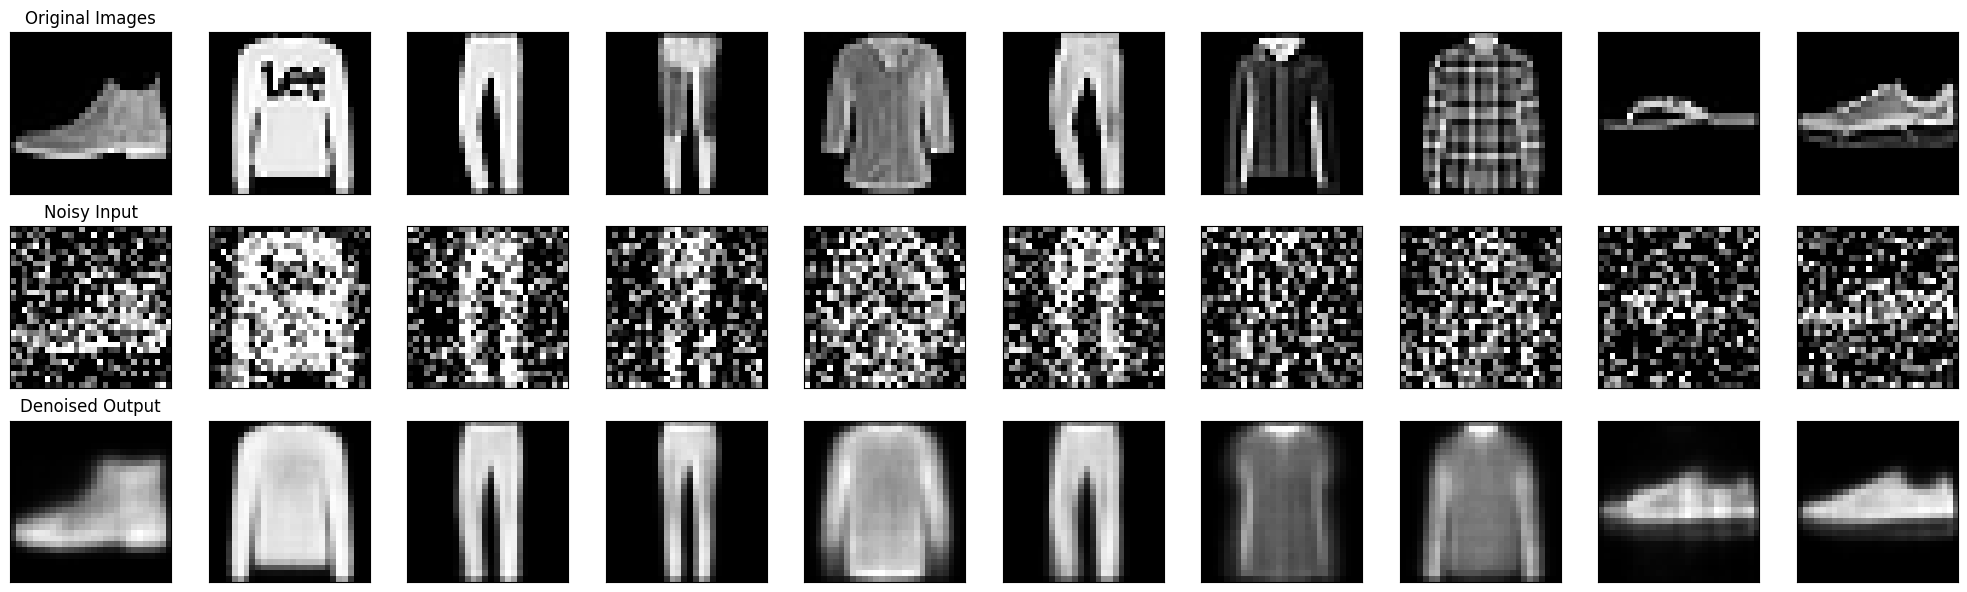

In [9]:
from keras.layers import Input, Dense, GaussianNoise
from keras.models import Model
from keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# Define the model architecture
# Define the size of our encoded representation
encoding_dim = 32

# Input placeholder with added noise
input_img = Input(shape=(784,))
noisy_img = GaussianNoise(0.5)(input_img)

# Encoded representation
encoded = Dense(encoding_dim, activation='relu')(noisy_img)

# Additional hidden layer
hidden_layer = Dense(64, activation='relu')(encoded)

# Decoded representation
decoded = Dense(784, activation='sigmoid')(hidden_layer)

# Denoising Autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the autoencoder (defaults to adam optimizer with default learning rate)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


# Load data
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))


# Introducing noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip the values to be between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Train the denoising autoencoder
autoencoder.fit(x_train_noisy, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

# Predict on the noisy test data
decoded_imgs = autoencoder.predict(x_test_noisy)


# Function to plot images
def plot_images(original_images, noisy_images, decoded_images, num_images=10):
    plt.figure(figsize=(20, 6))
    for i in range(num_images):
        # Original images
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0:
            ax.set_title('Original Images')

        # Noisy images
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0:
            ax.set_title('Noisy Input')

        # Reconstructed images
        ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)
        plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i == 0:
            ax.set_title('Denoised Output')
    plt.tight_layout()
    plt.show()

# Visualize original, noisy, and denoised images
plot_images(x_test, x_test_noisy, decoded_imgs)


Epoch 1/10
235/235 [==============================] - 2s 5ms/step - loss: 0.5992 - accuracy: 0.7988 - val_loss: 0.4840 - val_accuracy: 0.8296
Epoch 2/10
235/235 [==============================] - 1s 6ms/step - loss: 0.4268 - accuracy: 0.8509 - val_loss: 0.4326 - val_accuracy: 0.8484
Epoch 3/10
235/235 [==============================] - 1s 3ms/step - loss: 0.3839 - accuracy: 0.8653 - val_loss: 0.3983 - val_accuracy: 0.8596
Epoch 4/10
235/235 [==============================] - 1s 4ms/step - loss: 0.3551 - accuracy: 0.8744 - val_loss: 0.3795 - val_accuracy: 0.8660
Epoch 5/10
235/235 [==============================] - 1s 4ms/step - loss: 0.3437 - accuracy: 0.8779 - val_loss: 0.3955 - val_accuracy: 0.8579
Epoch 6/10
235/235 [==============================] - 1s 3ms/step - loss: 0.3235 - accuracy: 0.8843 - val_loss: 0.3651 - val_accuracy: 0.8697
Epoch 7/10
235/235 [==============================] - 1s 4ms/step - loss: 0.3114 - accuracy: 0.8894 - val_loss: 0.3550 - val_accuracy: 0.8744
Epoch 

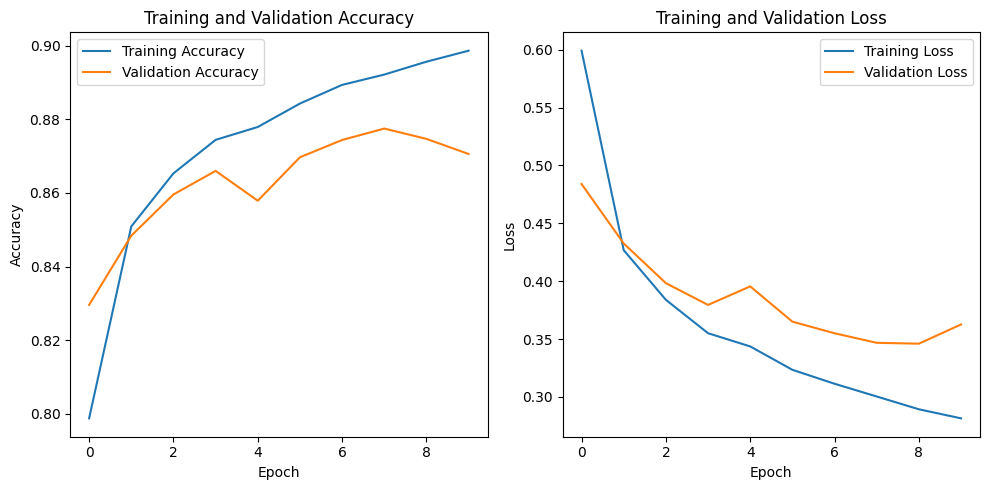

In [10]:
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from keras.optimizers import Adam

# Load and prepare the Fashion MNIST data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.reshape(-1, 784).astype('float32') / 255
x_test = x_test.reshape(-1, 784).astype('float32') / 255

# Convert labels to one-hot encoding
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# Model architecture
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
decoded = Dense(10, activation='softmax')(encoded)  # Classification layer

model = Model(input_img, decoded)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=256,
                    shuffle=True,
                    validation_data=(x_test, y_test))

# Plotting the training and validation loss
plt.figure(figsize=(10, 5))

# Plotting training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()